In [46]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import pyro
import pyro.distributions as dist
import pyro.poutine
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import ks_2samp

from dmm_triple import TripleDMM
from utils import log_returns, rogers_satchell_rv, realized_semivariance, yoy_log_change

pyro.set_rng_seed(42)
torch.manual_seed(42)

## Data loading

In [47]:
spy     = pd.read_csv('spy_ohlcv.csv',    index_col=0, parse_dates=True, skiprows=[1, 2])
t10y3m  = pd.read_csv('fred_t10y3m.csv',  index_col=0, parse_dates=True).squeeze()
baa10y  = pd.read_csv('fred_baa10y.csv',  index_col=0, parse_dates=True).squeeze()
dgs2    = pd.read_csv('fred_dgs2.csv',    index_col=0, parse_dates=True).squeeze()
icsa    = pd.read_csv('fred_icsa.csv',    index_col=0, parse_dates=True).squeeze()
cpi     = pd.read_csv('fred_cpi.csv',     index_col=0, parse_dates=True).squeeze()
umcsent = pd.read_csv('fred_umcsent.csv', index_col=0, parse_dates=True).squeeze()
vix     = pd.read_csv('fred_vix.csv',     index_col=0, parse_dates=True).squeeze()

# Quarterly S&P 500 EPS and DPS (actual reported figures, not Shiller monthly interpolation)
sp_q = pd.read_excel('sp500_more_data.xlsx').sort_values('Date').set_index('Date')
sp_q.index = pd.to_datetime(sp_q.index)

print('SPY range:', spy.index[0].date(), '→', spy.index[-1].date())
print('VIX range:', vix.first_valid_index().date(), '→', vix.last_valid_index().date())
print('Quarterly EPS/DPS range:', sp_q.index[0].date(), '→', sp_q.index[-1].date(), f'({len(sp_q)} quarters)')
sp_q.tail()

SPY range: 1993-01-29 → 2026-05-15
VIX range: 1990-01-02 → 2026-05-14
Quarterly EPS/DPS range: 1988-03-31 → 2025-09-30 (151 quarters)


,EPS,DPS
Date,,
2024-09-30,59.16,18.680400
2024-12-31,61.21,19.810500
2025-03-31,57.51,19.372895
2025-06-30,64.01,19.484935
2025-09-30,72.03,19.807819


## Feature engineering

In [ ]:
# ── Fast features (daily) ────────────────────────────────────────────────────
ret      = log_returns(spy['Close'])
rv       = np.log(rogers_satchell_rv(spy).clip(lower=1e-8))
rsv_down = realized_semivariance(log_returns(spy['Close']), window=5).clip(lower=1e-8)
log_vix  = np.log(vix.clip(lower=1e-8))
gap      = np.log(spy['Open'] / spy['Close'].shift(1))          # overnight gap return
log_vol  = np.log(spy['Volume'].clip(lower=1))
rel_vol  = log_vol - log_vol.ewm(span=63, adjust=False).mean()  # detrended log-volume

# ── Macro features ───────────────────────────────────────────────────────────
# ICSA is weekly; yoy_log_change over 52 periods = 1 year
icsa_yoy = yoy_log_change(icsa.dropna(), periods=52)

# CPI: shift index forward by 1 month for BLS release lag, then take YoY log
# change to get a stationary inflation rate series.
cpi_lagged = cpi.copy()
cpi_lagged.index = cpi_lagged.index + pd.DateOffset(months=1)
cpi_yoy = yoy_log_change(cpi_lagged, periods=12)

# ── Corporate features (quarterly) ───────────────────────────────────────────
# SPY closing price at each quarter-end date (ffill handles pre-SPY NaNs)
spy_close_q = spy['Close'].reindex(sp_q.index, method='ffill')

# EPS YoY %: clipped to [-100, 500] to handle the single negative-base quarter (Q4 2008 EPS = -$0.09)
eps_yoy      = sp_q['EPS'].pct_change(periods=4).multiply(100).clip(lower=-100, upper=500)
payout_ratio = (sp_q['DPS'] / sp_q['EPS']).clip(lower=0, upper=2)  # guard against negative EPS
earn_yield   = sp_q['EPS'] / spy_close_q

print('Corporate features (last 6 valid rows):')
corp_q = pd.DataFrame({'eps_yoy': eps_yoy, 'payout_ratio': payout_ratio, 'earn_yield': earn_yield})
print(corp_q.dropna().tail(6).round(4))

## Trading calendar & alignment

In [ ]:
K = 20   # trading days per slow period (≈ 1 month)
W = 5    # slow steps per training window

trading_days = ret.dropna().index

# ── Fast DataFrame (column order defines emission family blocks) ──────────────
# Student-t block (cols 0-3): ret, rv, log_vix, gap
# LogNormal block (col  4  ): rsv_down
# Normal    block (col  5  ): rel_vol
fast_raw = pd.DataFrame({
    'ret':      ret,
    'rv':       rv,
    'log_vix':  log_vix,
    'gap':      gap,
    'rsv_down': rsv_down,
    'rel_vol':  rel_vol,
}).reindex(trading_days).dropna()

T_fast_max = (len(fast_raw) // K) * K
fast_raw   = fast_raw.iloc[:T_fast_max]
T_slow_max = T_fast_max // K

# Slow period end dates: K-1, 2K-1, 3K-1, ... indices in fast_raw
slow_dates = fast_raw.index[K-1::K][:T_slow_max]

# ── Macro DataFrame (reindexed to slow_dates via ffill) ──────────────────────
macro_raw = pd.DataFrame({
    'T10Y3M':   t10y3m,
    'BAA10Y':   baa10y,
    'DGS2':     dgs2,
    'ICSA_yoy': icsa_yoy,
    'CPI_yoy':  cpi_yoy,       # YoY log change, publication-lag adjusted
    'UMCSENT':  umcsent,
}).ffill().reindex(slow_dates, method='ffill')

# ── Corporate DataFrame: quarterly data forward-filled to monthly slow_dates ──
corp_quarterly = pd.DataFrame({
    'eps_yoy':      eps_yoy,
    'payout_ratio': payout_ratio,
    'earn_yield':   earn_yield,
})
corp_raw = corp_quarterly.ffill().reindex(slow_dates, method='ffill')

# ── Trim to contiguous valid block (drops leading and trailing NaNs) ──────────
all_valid     = macro_raw.notna().all(axis=1) & corp_raw.notna().all(axis=1)
valid_indices = np.where(all_valid.values)[0]
start_idx     = int(valid_indices[0])
end_idx       = int(valid_indices[-1]) + 1   # exclusive

macro_df   = macro_raw.iloc[start_idx:end_idx]
corp_df    = corp_raw.iloc[start_idx:end_idx]
slow_dates = slow_dates[start_idx:end_idx]
T_slow     = len(macro_df)
T_fast     = T_slow * K
fast_df    = fast_raw.iloc[start_idx * K : start_idx * K + T_fast]

assert len(fast_df) == T_fast and len(corp_df) == T_slow
assert corp_df.isna().sum().sum() == 0 and macro_df.isna().sum().sum() == 0

print(f'Fast  : {fast_df.index[0].date()} → {fast_df.index[-1].date()}  ({T_fast} days)')
print(f'Slow  : {slow_dates[0].date()} → {slow_dates[-1].date()}  ({T_slow} periods)')
print(corp_df.describe().round(4))
print(macro_df.describe().round(3))

## Train / test split

In [50]:
n_train_slow = 280
n_test_slow  = 130
n_train_fast = n_train_slow * K
n_test_fast  = n_test_slow  * K

fast_train  = fast_df.iloc[:n_train_fast]
fast_test   = fast_df.iloc[n_train_fast : n_train_fast + n_test_fast]
macro_train = macro_df.iloc[:n_train_slow]
macro_test  = macro_df.iloc[n_train_slow : n_train_slow + n_test_slow]
corp_train  = corp_df.iloc[:n_train_slow]
corp_test   = corp_df.iloc[n_train_slow : n_train_slow + n_test_slow]
slow_train_dates = slow_dates[:n_train_slow]
slow_test_dates  = slow_dates[n_train_slow : n_train_slow + n_test_slow]

print(f'Train fast  : {fast_train.index[0].date()} \u2192 {fast_train.index[-1].date()}')
print(f'Test  fast  : {fast_test.index[0].date()} \u2192 {fast_test.index[-1].date()}')
print(f'Train slow  : {slow_train_dates[0].date()} \u2192 {slow_train_dates[-1].date()}')
print(f'Test  slow  : {slow_test_dates[0].date()} \u2192 {slow_test_dates[-1].date()}')

Train fast  : 1993-03-30 → 2015-06-25
Test  fast  : 2015-06-26 → 2025-10-27
Train slow  : 1993-04-27 → 2015-06-25
Test  slow  : 2015-07-24 → 2025-10-27


## Normalization
- Student-t / Normal features: `(x - μ_train) / σ_train`
- LogNormal features: `x / μ_train`  (keeps positivity, scales to O(1))

Parameters fit on training data only; applied to both splits.

In [51]:
# ── Fast: Student-t (cols 0-3: ret, rv, log_vix, gap)
#          LogNormal (col  4:   rsv_down)
#          Normal    (col  5:   rel_vol) ──────────────────────────────────────
f_tr = fast_train.values.astype(np.float32)
f_te = fast_test.values.astype(np.float32)

mu_f_st  = f_tr[:, :4].mean(0);  sig_f_st = f_tr[:, :4].std(0)
mu_f_ln  = f_tr[:, 4].mean()
mu_f_n   = f_tr[:, 5].mean();    sig_f_n  = f_tr[:, 5].std()

def norm_fast(arr):
    return np.concatenate([
        (arr[:, :4] - mu_f_st) / sig_f_st,   # Student-t block
         arr[:, 4:5] / mu_f_ln,               # LogNormal block
        (arr[:, 5:6] - mu_f_n) / sig_f_n,    # Normal block
    ], axis=1)

fast_train_norm = norm_fast(f_tr)
fast_test_norm  = norm_fast(f_te)

# ── Macro: all Normal (6 features) ───────────────────────────────────────────
m_tr = macro_train.values.astype(np.float32)
m_te = macro_test.values.astype(np.float32)

mu_m  = m_tr.mean(0);  sig_m = m_tr.std(0)
macro_train_norm = (m_tr - mu_m) / sig_m
macro_test_norm  = (m_te - mu_m) / sig_m

# ── Corporate: Normal (3 features — EPS YoY %, payout ratio, earnings yield) ──
c_tr = corp_train.values.astype(np.float32)
c_te = corp_test.values.astype(np.float32)

mu_c  = c_tr.mean(0);  sig_c = c_tr.std(0)
corp_train_norm = (c_tr - mu_c) / sig_c
corp_test_norm  = (c_te - mu_c) / sig_c

print('Fast   train:', fast_train_norm.shape, '| test:', fast_test_norm.shape)
print('Macro  train:', macro_train_norm.shape, '| test:', macro_test_norm.shape)
print('Corp   train:', corp_train_norm.shape, '| test:', corp_test_norm.shape)

Fast   train: (5600, 6) | test: (2600, 6)
Macro  train: (280, 6) | test: (130, 6)
Corp   train: (280, 3) | test: (130, 3)


## Windows & tensors

In [52]:
def make_windows(fast_arr, corp_arr, macro_arr, W, K):
    n = len(macro_arr) // W
    fw = np.stack([fast_arr[i*W*K  : (i+1)*W*K]  for i in range(n)])
    mw = np.stack([macro_arr[i*W   : (i+1)*W]    for i in range(n)])
    cw = np.stack([corp_arr[i*W    : (i+1)*W]    for i in range(n)])
    return fw, cw, mw

fast_wins, corp_wins, macro_wins = make_windows(
    fast_train_norm, corp_train_norm, macro_train_norm, W, K
)

xf_t = torch.tensor(fast_wins,  dtype=torch.float32)
xc_t = torch.tensor(corp_wins,  dtype=torch.float32)
xm_t = torch.tensor(macro_wins, dtype=torch.float32)

dataset     = TensorDataset(xf_t, xc_t, xm_t)
batch_size  = 32
loader      = DataLoader(dataset, batch_size=batch_size, shuffle=True)
diag_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

print(f'Windows : {len(fast_wins)}   (W={W}, K={K})')
print(f'xf: {xf_t.shape}   xc: {xc_t.shape}   xm: {xm_t.shape}')

# Full-sequence tensors for inference (batch dim = 1)
xf_train_seq = torch.tensor(fast_train_norm[None],  dtype=torch.float32)
xc_train_seq = torch.tensor(corp_train_norm[None],  dtype=torch.float32)
xm_train_seq = torch.tensor(macro_train_norm[None], dtype=torch.float32)
xf_test_seq  = torch.tensor(fast_test_norm[None],   dtype=torch.float32)
xc_test_seq  = torch.tensor(corp_test_norm[None],   dtype=torch.float32)
xm_test_seq  = torch.tensor(macro_test_norm[None],  dtype=torch.float32)

Windows : 56   (W=5, K=20)
xf: torch.Size([56, 100, 6])   xc: torch.Size([56, 5, 3])   xm: torch.Size([56, 5, 6])


## Model

In [53]:
# Latent dimensions
sm_dim = 3   # macro state
sc_dim = 1   # corporate state
f_dim  = 6   # fast state

hidden_dim       = 64
rnn_macro_hidden = 64
rnn_corp_hidden  = 32
rnn_fast_hidden  = 64
rnn_num_layers   = 1

# Emission family counts per layer
n_st_fast = 4;  n_ln_fast = 1;  n_n_fast = 1   # ret, rv, log_vix, gap → Student-t; rsv_down → LogNormal; rel_vol → Normal
n_st_corp = 0;  n_ln_corp = 0;  n_n_corp = 3   # eps_yoy, payout_ratio, earn_yield → Normal
n_st_macro = 0; n_ln_macro = 0; n_n_macro = 6  # all macro → Normal

pyro.clear_param_store()

dmm = TripleDMM(
    n_st_fast=n_st_fast, n_ln_fast=n_ln_fast, n_n_fast=n_n_fast,
    n_st_corp=n_st_corp, n_ln_corp=n_ln_corp, n_n_corp=n_n_corp,
    n_st_macro=n_st_macro, n_ln_macro=n_ln_macro, n_n_macro=n_n_macro,
    sm_dim=sm_dim, sc_dim=sc_dim, f_dim=f_dim,
    hidden_dim=hidden_dim,
    rnn_fast_hidden=rnn_fast_hidden,
    rnn_corp_hidden=rnn_corp_hidden,
    rnn_macro_hidden=rnn_macro_hidden,
    rnn_num_layers=rnn_num_layers,
    K=K,
    combiner = 'naive'
)
n_params = sum(p.numel() for p in dmm.parameters())
print(f'TripleDMM  |  parameters: {n_params:,}')

TripleDMM  |  parameters: 42,564


c:\Users\mikah\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\nn\modules\linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


## Training

In [54]:
def elbo_decomposition(model, guide, xf_b, xc_b, xm_b):
    """Decompose ELBO into per-layer reconstruction and KL terms."""
    guide_tr = pyro.poutine.trace(guide).get_trace(xf_b, xc_b, xm_b)
    model_tr = pyro.poutine.trace(
        pyro.poutine.replay(model, trace=guide_tr)
    ).get_trace(xf_b, xc_b, xm_b)

    macro_recon = corp_recon = fast_recon = 0.0
    kl_macro    = kl_corp    = kl_fast    = 0.0

    for name, site in model_tr.nodes.items():
        if site['type'] != 'sample':
            continue
        lp = site['fn'].log_prob(site['value']).sum().item()
        if name.startswith('x_macro_'):
            macro_recon += lp
        elif name.startswith('x_corp_'):
            corp_recon  += lp
        elif name.startswith('x_fast_'):
            fast_recon  += lp
        elif name.startswith('sm_') and name in guide_tr.nodes:
            lq = guide_tr.nodes[name]['fn'].log_prob(
                 guide_tr.nodes[name]['value']).sum().item()
            kl_macro += lq - lp
        elif name.startswith('sc_') and name in guide_tr.nodes:
            lq = guide_tr.nodes[name]['fn'].log_prob(
                 guide_tr.nodes[name]['value']).sum().item()
            kl_corp  += lq - lp
        elif name.startswith('f_') and name in guide_tr.nodes:
            lq = guide_tr.nodes[name]['fn'].log_prob(
                 guide_tr.nodes[name]['value']).sum().item()
            kl_fast  += lq - lp

    return macro_recon, corp_recon, fast_recon, kl_macro, kl_corp, kl_fast

[  0] loss=105676.19 | macro_recon=-1529.74  corp_recon=-655.01  fast_recon=-49088.54 | KL_macro=87.88  KL_corp=13.90  KL_fast=3726.83
[ 50] loss=40357.67 | macro_recon=-1149.97  corp_recon=-615.22  fast_recon=-20306.41 | KL_macro=88.27  KL_corp=9.99  KL_fast=763.41
[100] loss=33557.38 | macro_recon=-949.27  corp_recon=-611.58  fast_recon=-16229.72 | KL_macro=169.97  KL_corp=18.33  KL_fast=1168.82
[150] loss=31622.13 | macro_recon=-912.98  corp_recon=-605.75  fast_recon=-15377.33 | KL_macro=158.15  KL_corp=15.06  KL_fast=1163.93
[200] loss=31083.27 | macro_recon=-852.72  corp_recon=-592.57  fast_recon=-14980.46 | KL_macro=160.20  KL_corp=14.68  KL_fast=1081.00
[250] loss=30565.61 | macro_recon=-834.53  corp_recon=-600.88  fast_recon=-14825.90 | KL_macro=167.05  KL_corp=7.98  KL_fast=1104.93
[300] loss=30152.76 | macro_recon=-815.18  corp_recon=-562.60  fast_recon=-14701.21 | KL_macro=204.08  KL_corp=33.20  KL_fast=1166.54
[350] loss=30040.36 | macro_recon=-752.95  corp_recon=-536.73  f

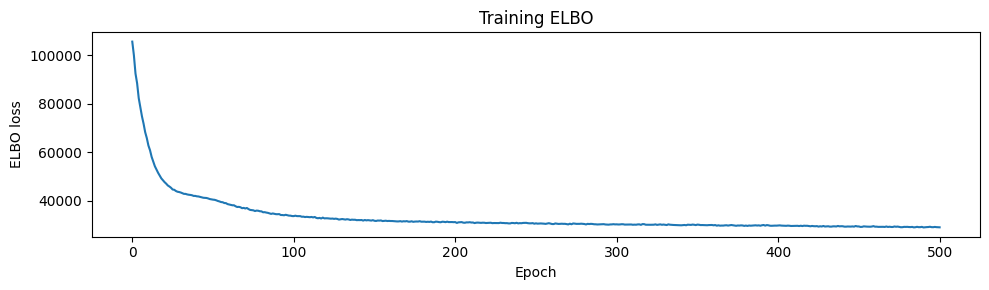

In [55]:
optimizer  = Adam({'lr': 1e-3})
svi        = SVI(dmm.model, dmm.guide, optimizer, loss=Trace_ELBO())
num_epochs = 501
losses     = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for xf_b, xc_b, xm_b in loader:
        epoch_loss += svi.step(xf_b, xc_b, xm_b)
    losses.append(epoch_loss)

    if epoch % 50 == 0:
        xf_d, xc_d, xm_d = next(iter(diag_loader))
        with torch.no_grad():
            mr, cr, fr, km, kc, kf = elbo_decomposition(
                dmm.model, dmm.guide, xf_d, xc_d, xm_d
            )
        print(
            f'[{epoch:3d}] loss={epoch_loss:.2f} | '
            f'macro_recon={mr:.2f}  corp_recon={cr:.2f}  fast_recon={fr:.2f} | '
            f'KL_macro={km:.2f}  KL_corp={kc:.2f}  KL_fast={kf:.2f}'
        )

plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('ELBO loss')
plt.title('Training ELBO')
plt.tight_layout()
plt.show()

## Inference

In [56]:
with torch.no_grad():
    (sm_means_tr, sm_stds_tr, sc_means_tr, sc_stds_tr, f_means_tr, f_stds_tr,
     macro_emit_tr, corp_emit_tr, fast_emit_tr) = dmm.infer(xf_train_seq, xc_train_seq, xm_train_seq)
    (sm_means_te, sm_stds_te, sc_means_te, sc_stds_te, f_means_te, f_stds_te,
     macro_emit_te, corp_emit_te, fast_emit_te) = dmm.infer(xf_test_seq,  xc_test_seq,  xm_test_seq)

# Squeeze batch dim → (T, dim)
sm_tr = sm_means_tr[0].numpy();  sm_te = sm_means_te[0].numpy()
sc_tr = sc_means_tr[0].numpy();  sc_te = sc_means_te[0].numpy()
f_tr  = f_means_tr[0].numpy();   f_te  = f_means_te[0].numpy()

print('sm_tr:', sm_tr.shape, ' sc_tr:', sc_tr.shape, ' f_tr:', f_tr.shape)
print('sm_te:', sm_te.shape, ' sc_te:', sc_te.shape, ' f_te:', f_te.shape)

# Emission params: each is a 7-tuple (df, st_mu, st_sigma, ln_mu, ln_sigma, n_mu, n_sigma)
# shapes: (1, T, n_*) — squeeze batch dim for convenience
_EMIT_KEYS = ('df', 'st_mu', 'st_sigma', 'ln_mu', 'ln_sigma', 'n_mu', 'n_sigma')
def emit_dict(emit_tuple, split):
    return {k: emit_tuple[i][0] for i, k in enumerate(_EMIT_KEYS)}

macro_ep_tr = emit_dict(macro_emit_tr, 'train')  # keys → (T_slow, n_*)
corp_ep_tr  = emit_dict(corp_emit_tr,  'train')
fast_ep_tr  = emit_dict(fast_emit_tr,  'train')  # keys → (T_fast, n_*)
macro_ep_te = emit_dict(macro_emit_te, 'test')
corp_ep_te  = emit_dict(corp_emit_te,  'test')
fast_ep_te  = emit_dict(fast_emit_te,  'test')

print('\nEmission param shapes (train):')
print('  macro n_mu :', macro_ep_tr['n_mu'].shape)
print('  corp  n_mu :', corp_ep_tr['n_mu'].shape)
print('  fast  df   :', fast_ep_tr['df'].shape,
      ' st_mu:', fast_ep_tr['st_mu'].shape,
      ' ln_mu:', fast_ep_tr['ln_mu'].shape)

sm_tr: (280, 3)  sc_tr: (280, 1)  f_tr: (5600, 6)
sm_te: (130, 3)  sc_te: (130, 1)  f_te: (2600, 6)

Emission param shapes (train):
  macro n_mu : torch.Size([280, 6])
  corp  n_mu : torch.Size([280, 3])
  fast  df   : torch.Size([5600, 4])  st_mu: torch.Size([5600, 4])  ln_mu: torch.Size([5600, 1])


## Diagnostics — PCA of latent states

In [57]:
# ── Market regime definitions ─────────────────────────────────────────────────
regime_colors = [
    ('Pre dot-com',  '#2196F3', '1993-01-01', '2000-03-10'),
    ('Dot-com bust', '#F44336', '2000-03-10', '2002-10-09'),
    ('Mid-cycle',    '#4CAF50', '2002-10-09', '2007-10-09'),
    ('GFC',          '#9C27B0', '2007-10-09', '2009-03-09'),
    ('Recovery',     '#FF9800', '2009-03-09', '2020-02-19'),
    ('COVID',        '#E91E63', '2020-02-19', '2021-06-01'),
    ('Post-COVID',   '#009688', '2021-06-01', '2030-01-01'),
]

def assign_regime_colors(dates):
    colors = np.empty(len(dates), dtype=object)
    for label, color, start, end in regime_colors:
        mask = (dates >= start) & (dates < end)
        colors[mask] = color
    return colors

fast_train_dates = fast_train.index
fast_test_dates  = fast_test.index
slow_tr_dates    = slow_train_dates
slow_te_dates    = slow_test_dates

regime_c_slow_tr = assign_regime_colors(slow_tr_dates.astype(str))
regime_c_slow_te = assign_regime_colors(slow_te_dates.astype(str))
regime_c_fast_tr = assign_regime_colors(fast_train_dates.astype(str))
regime_c_fast_te = assign_regime_colors(fast_test_dates.astype(str))

legend_patches = [mpatches.Patch(color=c, label=l) for l, c, _, _ in regime_colors]

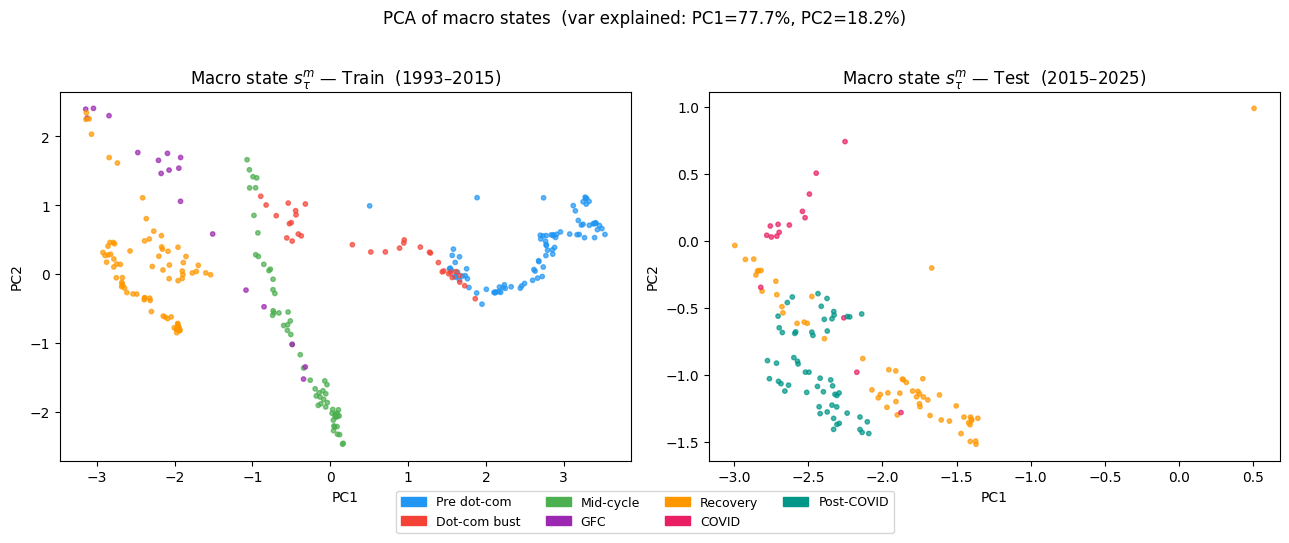

In [58]:
# ── PCA: macro states sm ──────────────────────────────────────────────────────
pca_sm = PCA(n_components=2).fit(sm_tr)
sm_tr_2d = pca_sm.transform(sm_tr)
sm_te_2d = pca_sm.transform(sm_te)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, z2d, c, title in [
    (axes[0], sm_tr_2d, regime_c_slow_tr, f'Train  ({slow_tr_dates[0].year}\u2013{slow_tr_dates[-1].year})'),
    (axes[1], sm_te_2d, regime_c_slow_te, f'Test  ({slow_te_dates[0].year}\u2013{slow_te_dates[-1].year})'),
]:
    ax.scatter(z2d[:, 0], z2d[:, 1], c=c, s=10, alpha=0.7)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Macro state $s^m_{{\\tau}}$ — {title}')

fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
ev = pca_sm.explained_variance_ratio_
fig.suptitle(f'PCA of macro states  (var explained: PC1={ev[0]:.1%}, PC2={ev[1]:.1%})', y=1.02)
plt.tight_layout()
plt.savefig('pca_macro.png', bbox_inches='tight', dpi=150)
plt.show()

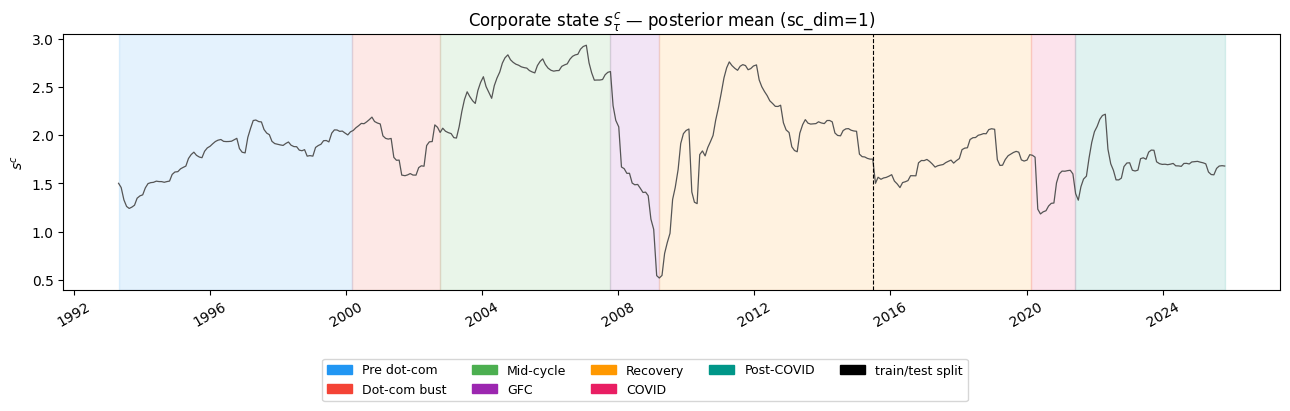

In [59]:
# ── Time series: corporate state sc (1-dimensional) ───────────────────────────
sc_all    = np.concatenate([sc_tr, sc_te], axis=0)          # (T_slow, 1)
sc_dates  = np.concatenate([slow_tr_dates, slow_te_dates])

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(sc_dates, sc_all[:, 0], lw=0.9, color='#555555')
ax.axvline(slow_tr_dates[-1], color='k', ls='--', lw=0.8, label='train/test split')

# colour regime bands
for label, color, start, end in regime_colors:
    ax.axvspan(max(pd.Timestamp(start), sc_dates[0]),
               min(pd.Timestamp(end),   sc_dates[-1]),
               alpha=0.12, color=color)

ax.set_title('Corporate state $s^c_{\\tau}$ — posterior mean (sc_dim=1)')
ax.set_ylabel('$s^c$')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
fig.legend(handles=legend_patches + [mpatches.Patch(color='k', label='train/test split')],
           loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.savefig('ts_corp.png', bbox_inches='tight', dpi=150)
plt.show()

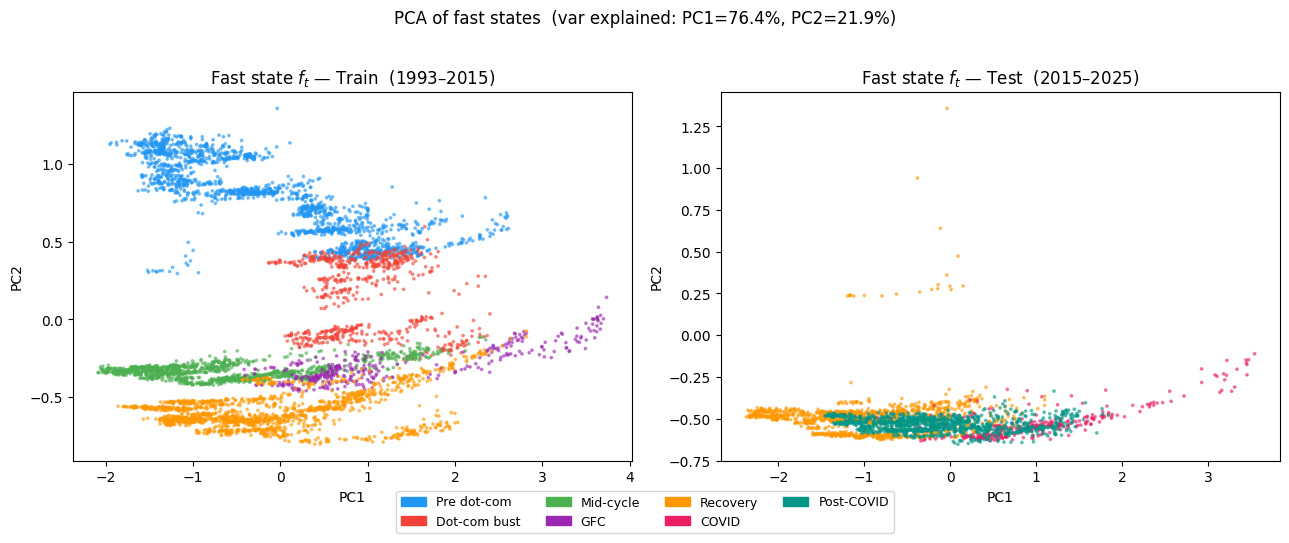

In [60]:
# ── PCA: fast states f (by market regime) ─────────────────────────────────────
pca_f = PCA(n_components=2).fit(f_tr)
f_tr_2d = pca_f.transform(f_tr)
f_te_2d = pca_f.transform(f_te)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, z2d, c, title in [
    (axes[0], f_tr_2d, regime_c_fast_tr, f'Train  ({fast_train_dates[0].year}\u2013{fast_train_dates[-1].year})'),
    (axes[1], f_te_2d, regime_c_fast_te, f'Test  ({fast_test_dates[0].year}\u2013{fast_test_dates[-1].year})'),
]:
    ax.scatter(z2d[:, 0], z2d[:, 1], c=c, s=3, alpha=0.5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Fast state $f_t$ — {title}')

fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
ev = pca_f.explained_variance_ratio_
fig.suptitle(f'PCA of fast states  (var explained: PC1={ev[0]:.1%}, PC2={ev[1]:.1%})', y=1.02)
plt.tight_layout()
plt.savefig('pca_fast.png', bbox_inches='tight', dpi=150)
plt.show()

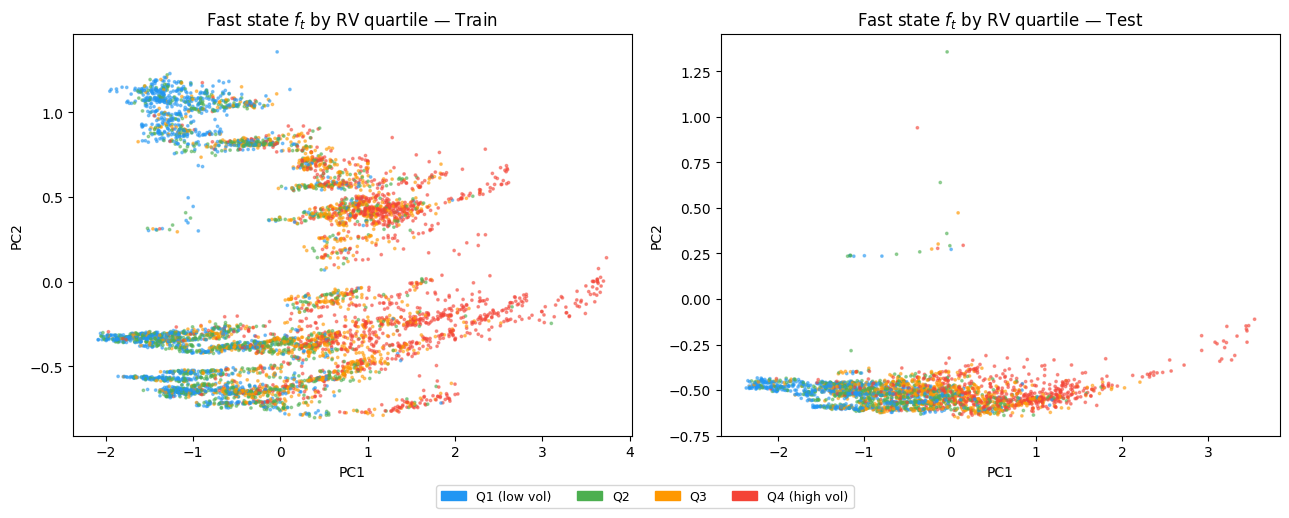

In [61]:
# ── PCA: fast states f (by realized-vol quartile) ─────────────────────────────
rv_train_raw = fast_train['rv'].values
rv_test_raw  = fast_test['rv'].values

def quartile_colors(vals):
    q = pd.qcut(vals, 4, labels=False)
    palette = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
    return np.array([palette[i] for i in q])

c_rv_tr = quartile_colors(rv_train_raw)
c_rv_te = quartile_colors(rv_test_raw)

rv_patches = [
    mpatches.Patch(color='#2196F3', label='Q1 (low vol)'),
    mpatches.Patch(color='#4CAF50', label='Q2'),
    mpatches.Patch(color='#FF9800', label='Q3'),
    mpatches.Patch(color='#F44336', label='Q4 (high vol)'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, z2d, c, title in [
    (axes[0], f_tr_2d, c_rv_tr, 'Train'),
    (axes[1], f_te_2d, c_rv_te, 'Test'),
]:
    ax.scatter(z2d[:, 0], z2d[:, 1], c=c, s=3, alpha=0.5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Fast state $f_t$ by RV quartile — {title}')

fig.legend(handles=rv_patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('pca_fast_rv_quartile.png', bbox_inches='tight', dpi=150)
plt.show()

C:\Users\mikah\AppData\Local\Temp\ipykernel_28524\2531978198.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


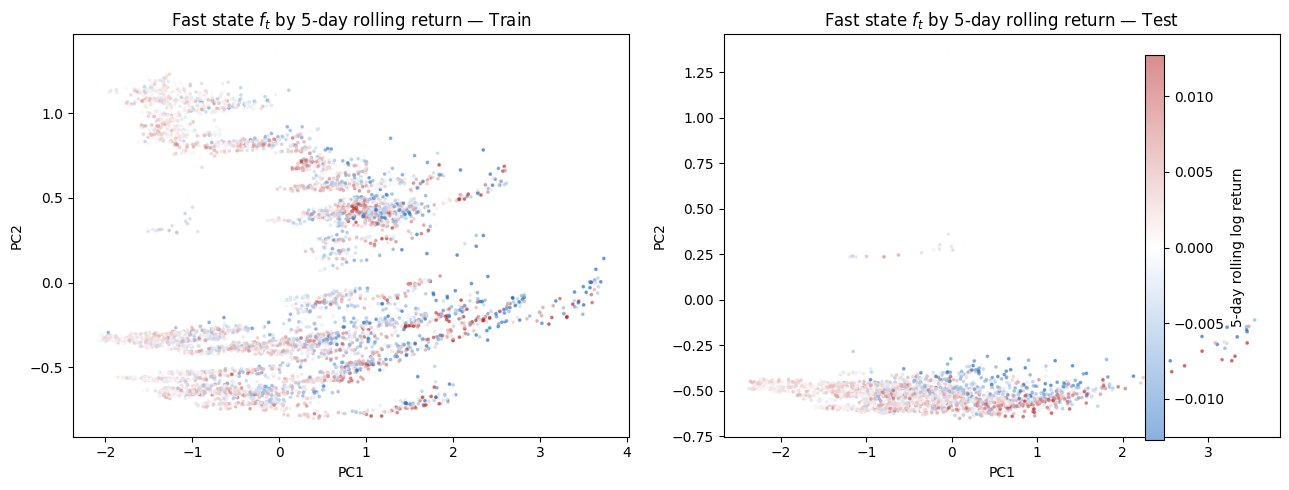

In [62]:
# ── PCA: fast states f (by 5-day rolling log return) ─────────────────────────
roll_ret_tr = pd.Series(fast_train['ret'].values).rolling(5).mean().fillna(0).values
roll_ret_te = pd.Series(fast_test['ret'].values).rolling(5).mean().fillna(0).values

all_rr = np.concatenate([roll_ret_tr, roll_ret_te])
vmax   = np.percentile(np.abs(all_rr), 98)

cmap_div = LinearSegmentedColormap.from_list('ret', ['#1565C0', '#FFFFFF', '#B71C1C'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, z2d, rr, title in [
    (axes[0], f_tr_2d, roll_ret_tr, 'Train'),
    (axes[1], f_te_2d, roll_ret_te, 'Test'),
]:
    sc = ax.scatter(z2d[:, 0], z2d[:, 1], c=rr, cmap=cmap_div,
                    vmin=-vmax, vmax=vmax, s=3, alpha=0.5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Fast state $f_t$ by 5-day rolling return — {title}')

fig.colorbar(sc, ax=axes, label='5-day rolling log return', fraction=0.02, pad=0.04)
plt.tight_layout()
plt.savefig('pca_fast_rolling_ret.png', bbox_inches='tight', dpi=150)
plt.show()

## Posterior predictive check (fast layer)
Sample from the fast emitter at the posterior mean of $f_t$ for two windows:
- **Pre-crisis (train)**: 2007-05 to 2007-08
- **COVID crash (test)**: 2020-02 to 2020-04

In [63]:
N_SAMPLES = 2000

def get_day_indices(dates, start, end):
    mask = (dates >= start) & (dates <= end)
    return np.where(mask)[0]

period_train_idx = get_day_indices(fast_train_dates, '2005-07-01', '2005-09-30')
period_test_idx  = get_day_indices(fast_test_dates,  '2022-01-01', '2022-05-30')

def sample_fast_ppc(f_states, idx):
    """Sample log return, RV, and log VIX; return samples and period-averaged emission params."""
    f_z = torch.tensor(f_states[idx], dtype=torch.float32)
    with torch.no_grad():
        df, st_mu, st_sigma, _, _, _, _ = dmm.fast_emitter(f_z)

    ret_samp  = dist.StudentT(df[:, 0:1], st_mu[:, 0:1], st_sigma[:, 0:1]) \
                    .sample((N_SAMPLES,)).squeeze(-1).numpy()
    rv_samp   = dist.StudentT(df[:, 1:2], st_mu[:, 1:2], st_sigma[:, 1:2]) \
                    .sample((N_SAMPLES,)).squeeze(-1).numpy()
    vix_samp  = dist.StudentT(df[:, 2:3], st_mu[:, 2:3], st_sigma[:, 2:3]) \
                    .sample((N_SAMPLES,)).squeeze(-1).numpy()

    ret_samp  = ret_samp  * sig_f_st[0] + mu_f_st[0]
    rv_samp   = np.exp(rv_samp  * sig_f_st[1] + mu_f_st[1])
    vix_samp  = np.exp(vix_samp * sig_f_st[2] + mu_f_st[2])

    params = {
        'df_ret':     float(df[:, 0].mean()),
        'ret_mu':     float(st_mu[:, 0].mean())    * sig_f_st[0] + mu_f_st[0],
        'ret_sigma':  float(st_sigma[:, 0].mean()) * sig_f_st[0],
        'df_rv':      float(df[:, 1].mean()),
        'rv_mu':      float(st_mu[:, 1].mean())    * sig_f_st[1] + mu_f_st[1],  # log(RV) space
        'rv_sigma':   float(st_sigma[:, 1].mean()) * sig_f_st[1],
        'df_vix':     float(df[:, 2].mean()),
        'vix_mu':     float(st_mu[:, 2].mean())    * sig_f_st[2] + mu_f_st[2],  # log(VIX) space
        'vix_sigma':  float(st_sigma[:, 2].mean()) * sig_f_st[2],
    }
    return ret_samp.ravel(), rv_samp.ravel(), vix_samp.ravel(), params

ret_ppc_tr, rv_ppc_tr, vix_ppc_tr, params_tr = sample_fast_ppc(f_tr, period_train_idx)
ret_ppc_te, rv_ppc_te, vix_ppc_te, params_te = sample_fast_ppc(f_te, period_test_idx)

ret_obs_tr  = fast_train_norm[period_train_idx, 0] * sig_f_st[0] + mu_f_st[0]
rv_obs_tr   = np.exp(fast_train_norm[period_train_idx, 1] * sig_f_st[1] + mu_f_st[1])
vix_obs_tr  = np.exp(fast_train_norm[period_train_idx, 2] * sig_f_st[2] + mu_f_st[2])

ret_obs_te  = fast_test_norm[period_test_idx, 0] * sig_f_st[0] + mu_f_st[0]
rv_obs_te   = np.exp(fast_test_norm[period_test_idx, 1] * sig_f_st[1] + mu_f_st[1])
vix_obs_te  = np.exp(fast_test_norm[period_test_idx, 2] * sig_f_st[2] + mu_f_st[2])

print(f'Train window days: {len(period_train_idx)}   Test window days: {len(period_test_idx)}')

Train window days: 64   Test window days: 102


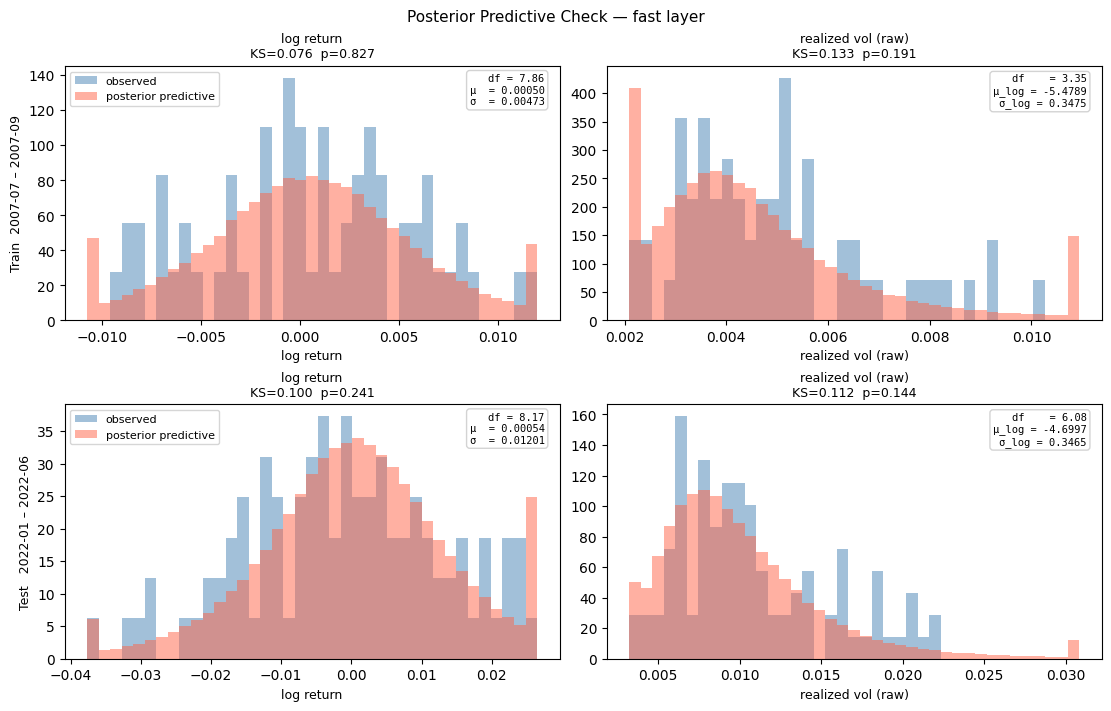

In [64]:
def ks_label(obs, ppc):
    stat, pval = ks_2samp(obs, ppc)
    return f'KS={stat:.3f}  p={pval:.3f}'

periods = [
    ('Train  2007-07 – 2007-09', ret_obs_tr, rv_obs_tr, ret_ppc_tr, rv_ppc_tr, params_tr),
    ('Test   2022-01 – 2022-06', ret_obs_te, rv_obs_te, ret_ppc_te, rv_ppc_te, params_te),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
_box = dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.85)

for row, (period_label, ro, rvo, rp, rvp, prm) in enumerate(periods):
    # log return
    ax = axes[row, 0]
    lo, hi = np.percentile(ro, 1), np.percentile(ro, 99)
    bins = np.linspace(lo, hi, 40)
    ax.hist(ro, bins=bins, density=True, alpha=0.5, color='steelblue', label='observed')
    ax.hist(np.clip(rp, lo, hi), bins=bins, density=True, alpha=0.5, color='tomato', label='posterior predictive')
    ax.set_title(f'log return\n{ks_label(ro, rp)}', fontsize=9)
    ax.set_xlabel('log return', fontsize=9)
    ax.set_ylabel(period_label, fontsize=9)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97,
            f'df = {prm["df_ret"]:.2f}\n'
            f'μ  = {prm["ret_mu"]:.5f}\n'
            f'σ  = {prm["ret_sigma"]:.5f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            family='monospace', bbox=_box)

    # realized vol
    ax = axes[row, 1]
    lo, hi = np.percentile(rvo, 1), np.percentile(rvo, 99)
    bins = np.linspace(lo, hi, 40)
    ax.hist(rvo, bins=bins, density=True, alpha=0.5, color='steelblue', label='observed')
    ax.hist(np.clip(rvp, lo, hi), bins=bins, density=True, alpha=0.5, color='tomato', label='posterior predictive')
    ax.set_title(f'realized vol (raw)\n{ks_label(rvo, rvp)}', fontsize=9)
    ax.set_xlabel('realized vol (raw)', fontsize=9)
    ax.text(0.97, 0.97,
            f'df    = {prm["df_rv"]:.2f}\n'
            f'μ_log = {prm["rv_mu"]:.4f}\n'
            f'σ_log = {prm["rv_sigma"]:.4f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            family='monospace', bbox=_box)

fig.suptitle('Posterior Predictive Check — fast layer', fontsize=11)
plt.savefig('ppc_fast.png', bbox_inches='tight', dpi=150)
plt.show()

## Time-series: posterior means of all three latent states

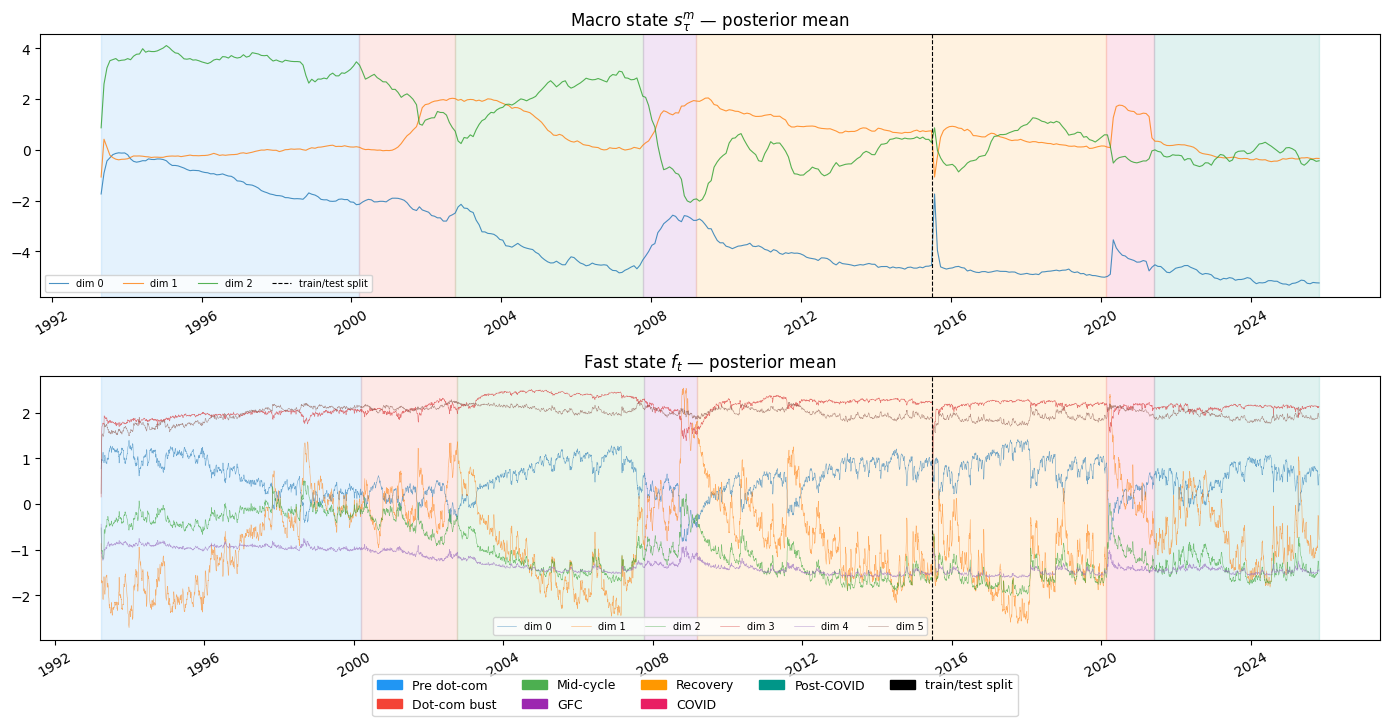

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Macro (slow)
sm_all = np.concatenate([sm_tr, sm_te], axis=0)
sm_dates_all = np.concatenate([slow_tr_dates, slow_te_dates])
for label, color, start, end in regime_colors:
    axes[0].axvspan(max(pd.Timestamp(start), sm_dates_all[0]),
                    min(pd.Timestamp(end),   sm_dates_all[-1]),
                    alpha=0.12, color=color)
for i in range(sm_dim):
    axes[0].plot(sm_dates_all, sm_all[:, i], lw=0.8, alpha=0.8, label=f'dim {i}')
axes[0].axvline(slow_tr_dates[-1], color='k', ls='--', lw=0.8, label='train/test split')
axes[0].set_title('Macro state $s^m_\\tau$ — posterior mean')
axes[0].legend(fontsize=7, ncol=sm_dim + 1)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Fast (daily)
f_all = np.concatenate([f_tr, f_te], axis=0)
f_dates_all = np.concatenate([fast_train_dates, fast_test_dates])
for label, color, start, end in regime_colors:
    axes[1].axvspan(max(pd.Timestamp(start), f_dates_all[0]),
                    min(pd.Timestamp(end),   f_dates_all[-1]),
                    alpha=0.12, color=color)
for i in range(f_dim):
    axes[1].plot(f_dates_all, f_all[:, i], lw=0.4, alpha=0.6, label=f'dim {i}')
axes[1].axvline(fast_train_dates[-1], color='k', ls='--', lw=0.8)
axes[1].set_title('Fast state $f_t$ — posterior mean')
axes[1].legend(fontsize=7, ncol=f_dim)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.legend(handles=legend_patches + [mpatches.Patch(color='k', label='train/test split')],
           loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('latent_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()

In [21]:
import numpy as np
np.savez('dmm_artifacts.npz',
    # ── Fast latent states ────────────────────────────────────────────────────
    f_tr              = f_tr,
    f_te              = f_te,
    f_std_tr          = f_stds_tr[0].numpy(),
    f_std_te          = f_stds_te[0].numpy(),
    # ── Corporate latent state ────────────────────────────────────────────────
    sc_tr             = sc_tr,
    sc_te             = sc_te,
    sc_std_tr         = sc_stds_tr[0].numpy(),
    sc_std_te         = sc_stds_te[0].numpy(),
    # ── Macro latent state ────────────────────────────────────────────────────
    sm_tr             = sm_tr,
    sm_te             = sm_te,
    sm_std_tr         = sm_stds_tr[0].numpy(),
    sm_std_te         = sm_stds_te[0].numpy(),
    # ── Fast emission params ──────────────────────────────────────────────────
    fast_ep_tr_df     = fast_ep_tr['df'],
    fast_ep_tr_st_mu  = fast_ep_tr['st_mu'],
    fast_ep_tr_st_sig = fast_ep_tr['st_sigma'],
    fast_ep_tr_ln_mu  = fast_ep_tr['ln_mu'],
    fast_ep_tr_ln_sig = fast_ep_tr['ln_sigma'],
    fast_ep_tr_n_mu   = fast_ep_tr['n_mu'],
    fast_ep_tr_n_sig  = fast_ep_tr['n_sigma'],
    fast_ep_te_df     = fast_ep_te['df'],
    fast_ep_te_st_mu  = fast_ep_te['st_mu'],
    fast_ep_te_st_sig = fast_ep_te['st_sigma'],
    fast_ep_te_ln_mu  = fast_ep_te['ln_mu'],
    fast_ep_te_ln_sig = fast_ep_te['ln_sigma'],
    fast_ep_te_n_mu   = fast_ep_te['n_mu'],
    fast_ep_te_n_sig  = fast_ep_te['n_sigma'],
    # ── Dates and raw returns ─────────────────────────────────────────────────
    log_ret_tr        = fast_train['ret'].values,
    log_ret_te        = fast_test['ret'].values,
    fast_train_dates  = fast_train.index.astype(str),
    fast_test_dates   = fast_test.index.astype(str),
)
print('Saved dmm_artifacts.npz')

Saved dmm_artifacts.npz
